## 실습 문제 1: 정규분포 샘플링 및 시각화

정규분포(Normal Distribution)는 연속 확률 분포 중 가장 기본이 되는 분포입니다. 이 실습에서는 NumPy를 사용해 정규분포에서 샘플을 생성하고, 히스토그램을 통해 분포 특성을 시각화합니다.

$$ f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\Bigl(-\frac{(x-\mu)^2}{2\sigma^2}\Bigr) $$

$ \mu $ : 평균
$ \sigma\ $: 표준편차

**요구사항**

1. 표준 정규분포에서 n=1000개의 샘플 생성합니다. (평균 0, 표준편차 1, np.random.normal)

2. 구간 [−4, 4]에 대해 x 값을 1000개, f(x) 로 y 값을 1000개 계산합니다.

3. Matplotlib으로 히스토그램을 그립니다. 이때 density=True로 설정해 샘플의 밀도 분포를 그립니다.

In [85]:
import numpy as np
import matplotlib.pyplot as plt

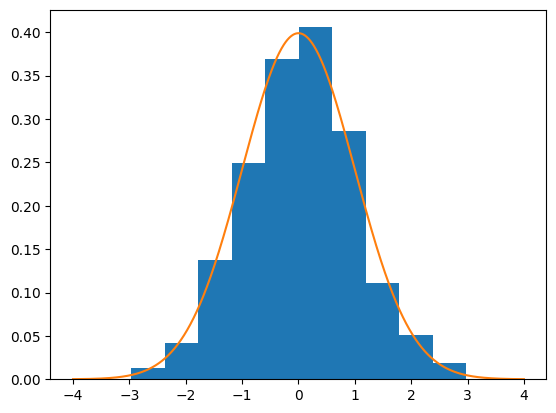

In [86]:
# 교수님 version
def f1(x, mu=0, std=1):
    first = 1/(std*np.sqrt(2*np.pi))
    second = np.exp(-((x-mu)**2)/2*std**2)
    return first*second

samples = np.random.normal(0, 1, 1000)
x = np.linspace(-4, 4, 1000)
y = f1(x)

plt.hist(samples, density=True)
plt.plot(x, y)

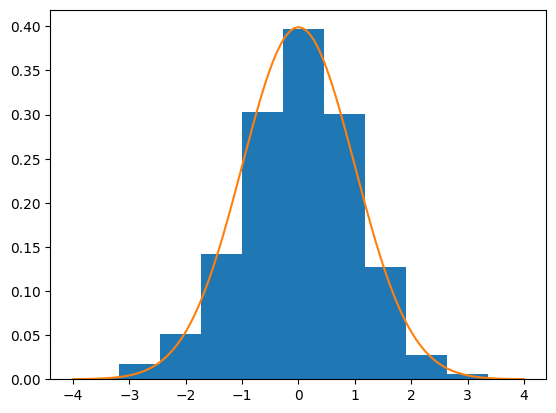

In [87]:
# 내가 한 거 => 너무 복잡해 보임
def f(x):
    return (1/(1*np.sqrt(2*np.pi)))*np.exp((-((x-0)**2))/(2*1**2))

samples = np.random.normal(0, 1, 1000)
x = np.linspace(-4, 4, 1000)
y = f(x)

plt.hist(samples, density=True)
plt.plot(x, y)

## 실습 문제 2: 학생 성적 데이터 비교 시각화

학생들의 수학(Math)과 과학(Science) 점수를 독립적으로 생성한 경우와 상관 관계가 있는 경우로 나누어 데이터를 생성하고, 분포 형태를 시각적으로 비교합니다.

구체적으로 1과 2의 jointplot을 비교하고, 중앙 산점도 분포 모양에서 관찰되는 주요 차이점(타원 형태 vs. 둥근 구름 형태 등)을 확인하세요. 공분산 항이 분포의 “방향성”과 “길이”에 어떤 영향을 미쳤는지 생각해 보세요.

**요구사항:**

1. 독립적인 점수

* 수학 점수: 평균 70, 표준편차 10을 갖는 정규 분포에서 1000명 샘플 생성합니다. (np.random.normal)
* 과학 점수: 평균 75, 표준편차 15을 갖는 정규 분포에서 1000명 샘플 생성합니다. (수학 점수와 독립이라고 가정함)
* 생성된 데이터를 seaborn.jointplot(kind="scatter")으로 시각화합니다. (p. 349)

    * x축 레이블: "Math Score (Independent)"
    * y축 레이블: "Science Score (Independent)"
    * 제목: "Independent Student Scores"

2. 상관 관계가 있는 점수

* 평균 벡터 $$ \mu = [70,\;75] $$

* 공분산 (양의 상관관계일 경우, 수학 점수가 높으면 과학 점수도 높음) 행렬

$$ \Sigma =
  \begin{bmatrix}
    100 & 80 \\
     80 &225
  \end{bmatrix} $$

* numpy.random.multivariate_normal(μ, Σ, size=1000)으로 1000명 샘플 생성합니다. (p. 344)
* 생성된 데이터를 seaborn.jointplot(kind="scatter")으로 시각화합니다.

    * x축 레이블: "Math Score (Correlated)"
    * y축 레이블: "Science Score (Correlated)"
    * 제목: "Correlated Student Scores (Multivariate Normal)"


In [88]:
import seaborn

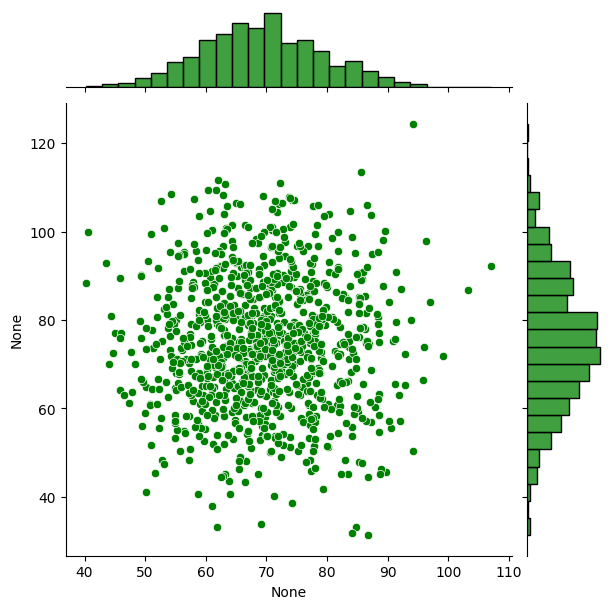

In [89]:
math = np.random.normal(70, 10, 1000)
science = np.random.normal(75, 15, 1000)
seaborn.jointplot(x=math, y=science, kind="scatter", color="green")
# 동그랗게 나오니까 독립이네 라고 생각해야 함 (잘 못들었음)

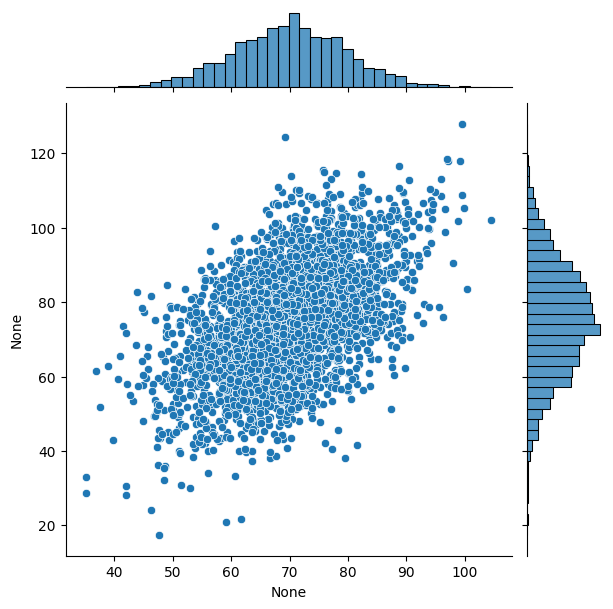

In [90]:
average = np.array([70, 75])
cov = np.array([[100, 80],
    [80, 225]])

data = np.random.multivariate_normal(average, cov, size=3000)
x_data = data[:, 0]
y_data = data[:, 1]
seaborn.jointplot(x=x_data, y=y_data, kind="scatter")

## 실습 문제 3: Pandas를 이용한 국가 통계 분석

주어진 CSV 파일을 읽고, pandas 기반으로 국가별 통계를 쉽게 분석할 수 있도록 CountryStatistics 클래스를 작성하세요.

* 파일 url: https://gist.githubusercontent.com/vr-23/d6a4a0aadcf3a2640091ca43c25e1955/raw/57b9cb74b24dc87b489c74cc4e11209cd5720642/world-data-2023.csv

### CountryStatistics 클래스
* load_data(self, filename: str) -> None: pd.read_csv로 파일을 읽고, 숫자형 열(예: GDP, Life expectancy, Population, Area 등)에 대해 쉼표(,), 달러($), 백분율(%) 기호를 제거한 뒤 pd.to_numeric으로 변환하여 self.df에 저장합니다. 또한, 데이터 로드 완료 시점의 datetime을 self.load_time에 저장합니다.

* top_5_gdp(self) -> pd.DataFrame: GDP 열 기준 내림차순 정렬 후 상위 5개 국가의 (국가명, “1,234,567.89” 형태의 문자열) 반환합니다.

* top_5_life_expectancy(self) -> pd.DataFrame: 기대수명 열 기준 내림차순 정렬 후 상위 5개 국가의 (국가명, 기대수명) 반환합니다.

* top_5_density(self) -> pd.DataFrame: 인구밀도(Population ÷ Area)를 계산해 새 열을 추가한 뒤 내림차순 정렬, 상위 5개 국가의 (국가명, 밀도) 반환합니다.

In [128]:
import pandas as pd
import datetime as dt
import plotly.express as px

pd.set_option('display.float_format', lambda x: '%.3f' % x)


class CountryStatistics:
    def __init__(self):
        self.df = None
        self.load_time = None

    def load_data(self, filename: str) -> None:
        self.df = pd.read_csv(filename)
        self.df.loc[:, 'GDP'] = self.df.loc[:, 'GDP'].str.replace('$', '').replace('%', '').replace(',', '')

    def top_5_gdp(self) -> pd.DataFrame:
        return self.df['GDP'].sort_values(ascending=False).head(5)

    def top_5_life_expectancy(self) -> pd.DataFrame:
        return self.df['Life expectancy'].sort_values(ascending=False).head(5)

    def top_5_density(self) -> pd.DataFrame:
        return self.df['Density (P/Km2)'].sort_values(ascending=False).head(5)

    def get_data_load_time(self) -> dt.datetime:
        date = dt.datetime.now()
        return date.strftime('%Y-%m-%d')

    def plot_geo_scatter(self):
        fig = px.scatter_geo(
            self.df,
            lat='Latitude',
            lon='Longitude',
            hover_name='Country',
            size='Population',
            projection='natural earth'
        )
        return fig


file_url = 'https://gist.githubusercontent.com/vr-23/d6a4a0aadcf3a2640091ca43c25e1955/raw/57b9cb74b24dc87b489c74cc4e11209cd5720642/world-data-2023.csv'
cs = CountryStatistics()
cs.load_data(file_url)
print(f'gdp 상위 5 : \n{cs.top_5_gdp()}\n')
print(f'life_expectancy 상위 5 : \n{cs.top_5_life_expectancy()}\n')
cs.get_data_load_time()

gdp 상위 5 : 
57      96,107,662,398 
88      95,503,088,538 
4       94,635,415,870 
189        917,058,851 
122    909,070,395,161 
Name: GDP, dtype: object

life_expectancy 상위 5 : 
149   85.400
85    84.200
169   83.600
164   83.300
156   83.100
Name: Life expectancy, dtype: float64



'2025-05-12'

In [92]:
file_url = 'https://gist.githubusercontent.com/vr-23/d6a4a0aadcf3a2640091ca43c25e1955/raw/57b9cb74b24dc87b489c74cc4e11209cd5720642/world-data-2023.csv'
df = pd.read_csv(file_url)
df.head()
df.keys()

Index(['Country', 'Density (P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

## 목표

미국 주별 2010년 인구 밀도를 계산하고, 인구 밀도가 높은 순서대로 정렬하여 상위 5개 주를 확인합니다.

## 데이터셋

이 실습에서는 다음 세 가지 공개 데이터를 사용합니다. 각 링크에서 데이터를 다운로드하거나, pd.read_csv() 함수에 직접 URL을 입력하여 사용하세요.

* 주별 인구 데이터 (state-population.csv): https://raw.githubusercontent.com/jakevdp/data-usstates/master/state-population.csv

* 주별 면적 데이터 (state-areas.csv): https://raw.githubusercontent.com/jakevdp/data-USstates/master/state-areas.csv

* 주 약자 및 전체 이름 데이터 (state-abbrevs.csv): https://raw.githubusercontent.com/jakevdp/data-USstates/master/state-abbrevs.csv



In [93]:
url1 = 'https://raw.githubusercontent.com/jakevdp/data-usstates/master/state-population.csv'
url2 = 'https://raw.githubusercontent.com/jakevdp/data-USstates/master/state-areas.csv'
url3 = 'https://raw.githubusercontent.com/jakevdp/data-USstates/master/state-abbrevs.csv'

In [94]:
pop = pd.read_csv(url1)
pop.head()

,state/region,ages,year,population
0,AL,under18,2012,1117489.000
1,AL,total,2012,4817528.000
2,AL,under18,2010,1130966.000
3,AL,total,2010,4785570.000
4,AL,under18,2011,1125763.000


In [95]:
pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2544 entries, 0 to 2543
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   state/region  2544 non-null   object 
 1   ages          2544 non-null   object 
 2   year          2544 non-null   int64  
 3   population    2524 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 79.6+ KB


In [96]:
areas = pd.read_csv(url2)
areas.head()

,state,area (sq. mi)
0,Alabama,52423
1,Alaska,656425
2,Arizona,114006
3,Arkansas,53182
4,California,163707


In [97]:
areas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   state          52 non-null     object
 1   area (sq. mi)  52 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 960.0+ bytes


In [98]:
abbrevs = pd.read_csv(url3)
abbrevs.head()

,state,abbreviation
0,Alabama,AL
1,Alaska,AK
2,Arizona,AZ
3,Arkansas,AR
4,California,CA


In [99]:
abbrevs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   state         51 non-null     object
 1   abbreviation  51 non-null     object
dtypes: object(2)
memory usage: 944.0+ bytes


In [115]:
merged = pd.merge(pop, abbrevs, how='outer', left_on='state/region', right_on='abbreviation').drop('abbreviation', axis=1)
merged.loc[merged['state'].isnull(), 'state/region'].unique()
merged.isnull().any()

merged = pd.merge(merged, areas, how='outer', left_on='state', right_on='state')
merged['population']/merged['area (sq. mi)']
merged['인구밀도'] = merged['population']/merged['area (sq. mi)']
merged.sort_values('인구밀도', ascending=False)[:5]

,state/region,ages,year,population,state,area (sq. mi),인구밀도
391,DC,total,2013.000,646449.000,District of Columbia,68.000,9506.603
385,DC,total,2012.000,633427.000,District of Columbia,68.000,9315.103
387,DC,total,2011.000,619624.000,District of Columbia,68.000,9112.118
431,DC,total,1990.000,605321.000,District of Columbia,68.000,8901.779
389,DC,total,2010.000,605125.000,District of Columbia,68.000,8898.897


In [ ]:
print(merged.loc[merged['state'].isnull(), 'state/region'].unique())
merged.loc[merged['state/region'] == 'PR', 'state'] = 'Puerto Rico'
merged.loc[merged['state/region'] == 'USA', 'state'] = 'United States'
merged.to_csv('merged_pop_abbrevs.csv', index=False) # index=False => 인덱스는 저장하지 않게 해줌

['PR' 'USA']


In [117]:
merged[merged['population'].isnull()].head()

,state/region,ages,year,population,state,area (sq. mi),인구밀도
1872,NaN,NaN,NaN,NaN,Puerto Rico,3515.000,NaN
2449,PR,under18,1990.000,NaN,Puerto Rico,NaN,NaN
2450,PR,total,1990.000,NaN,Puerto Rico,NaN,NaN
2451,PR,total,1991.000,NaN,Puerto Rico,NaN,NaN
2452,PR,under18,1991.000,NaN,Puerto Rico,NaN,NaN


In [118]:
merged.loc[merged['state/region'] == 'PR', 'state'] = 'Puerto Rico'
merged.loc[merged['state/region'] == 'USA', 'state'] = 'United States'

print(merged['state'].isnull().any())

False


In [119]:
merged.to_csv('merged_pop_abbrevs.csv', index=False)

In [129]:
final_merged = pd.read_csv('merged_pop_abbrevs.csv')
final_merged.head()

,state/region,ages,year,population,state,area (sq. mi),인구밀도
0,AL,under18,2012.000,1117489.000,Alabama,52423.000,21.317
1,AL,total,2012.000,4817528.000,Alabama,52423.000,91.897
2,AL,under18,2010.000,1130966.000,Alabama,52423.000,21.574
3,AL,total,2010.000,4785570.000,Alabama,52423.000,91.288
4,AL,under18,2011.000,1125763.000,Alabama,52423.000,21.475


In [ ]:
# select
# from final_merged, areas
# where final_merged.state = areas.state

In [ ]:
# select *
# from final_merged left outer join areas
#   on ............

In [131]:
final_merged = pd.read_csv('merged_pop_abbrevs.csv')
final_data = pd.merge(final_merged, areas, on='state', how='left').drop('area (sq. mi)_y', axis=1)
print(final_data.head())
print(final_data.isnull().any())

print(final_data.loc[final_data['area (sq. mi)_x'].isnull(), 'state'].unique())
final_data.dropna()
print(final_data.head())
final_data.to_csv('final_state_data.csv', index=False)

  state/region     ages     year  population    state  area (sq. mi)_x   인구밀도
0           AL  under18 2012.000 1117489.000  Alabama        52423.000 21.317
1           AL    total 2012.000 4817528.000  Alabama        52423.000 91.897
2           AL  under18 2010.000 1130966.000  Alabama        52423.000 21.574
3           AL    total 2010.000 4785570.000  Alabama        52423.000 91.288
4           AL  under18 2011.000 1125763.000  Alabama        52423.000 21.475
state/region        True
ages                True
year                True
population          True
state              False
area (sq. mi)_x     True
인구밀도                True
dtype: bool
['Puerto Rico' 'United States']
  state/region     ages     year  population    state  area (sq. mi)_x   인구밀도
0           AL  under18 2012.000 1117489.000  Alabama        52423.000 21.317
1           AL    total 2012.000 4817528.000  Alabama        52423.000 91.897
2           AL  under18 2010.000 1130966.000  Alabama        52423.000 21.574
3

In [ ]:
# select 
# from data
# where year = 2010 and ages = 'total'
# order by areas desc
# limit 5

In [132]:
data_for_analysis = pd.read_csv('final_state_data.csv')
data2010 = data_for_analysis.query("year == 2010 & ages == 'total'")
print(data2010.head())
data2010.set_index('state')
density = data2010['population'] / data2010['area (sq. mi)_x']
density.sort_values(ascending=False)
print(density.head())

    state/region   ages     year   population       state  area (sq. mi)_x  \
3             AL  total 2010.000  4785570.000     Alabama        52423.000   
91            AK  total 2010.000   713868.000      Alaska       656425.000   
101           AZ  total 2010.000  6408790.000     Arizona       114006.000   
189           AR  total 2010.000  2922280.000    Arkansas        53182.000   
197           CA  total 2010.000 37333601.000  California       163707.000   

       인구밀도  
3    91.288  
91    1.088  
101  56.214  
189  54.949  
197 228.051  
3      91.288
91      1.088
101    56.214
189    54.949
197   228.051
dtype: float64
